# Validating the DTC-IS Greenland Ice Sheet mass balance

This notebook walks through the DTC-IS mass-balance chain for the **Greenland Ice Sheet** and validates it
against independent observations of the same quantity. Everything the digital twin contributes is requested
from the **DTC Query API**, so the notebook reproduces exactly what a user of the twin can obtain.

**Key features:**
- **Mass-balance prediction:** Run the DTC-IS machine-learning mass-balance model on the present-day state of
  the ice sheet and map the predicted mass balance.
- **Scenario exploration:** Push the model with "what-if" changes to ice velocity, surface temperature and
  radar elevation change, and see how the ice-sheet total responds.
- **Annual DTC-IS series:** Retrieve the precomputed DTC-IS mass-balance product and aggregate it to annual
  ice-sheet totals in Gt/yr.
- **Annual model prediction:** Apply the same machine-learning model once per calendar year, on that year's
  own features, so the model itself can be validated year by year and not only as a present-day rate.
- **Independent validation data:** Collect the two reference records used by the community, IMBIE-3 and the
  GRACE/GRACE-FO gravimetric mass balance (GMB).
- **Intercomparison:** Present the year-by-year comparison as a table with agreement statistics, and as a
  four-panel validation figure.

**How to use this notebook:**
1. Run the setup cells and paste your DTC-IS API token when prompted.
2. Run the prediction, then optionally explore a what-if scenario.
3. Retrieve the annual DTC-IS series, apply the model year by year, and collect the two reference records.
4. Build the intercomparison table and the validation figure, and read the statistics.

**Why compare several records?**
No single technique measures ice-sheet mass balance without error. Satellite altimetry (the DTC-IS product),
the multi-technique reconciliation of IMBIE, and satellite gravimetry each carry their own error structure, so
the spread *between the references* is the yardstick against which the DTC-IS residuals should be read. The
annual model prediction is added as a fourth series and given exactly the same treatment, which separates how
well the model reproduces the ice sheet from how well its training product does. All four are reported on the
same calendar-year grid and with the same statistics.

**Requirements:**
- Jupyter (or VS Code with the Jupyter extension), and internet access to the DTC-IS API and to the two
  reference archives.
- A DTC-IS API token, which you can generate at
  [query.dtc-ice-sheets.org](https://query.dtc-ice-sheets.org/auth/get-token).
- The annual model prediction in section 2 is optional: it needs `cloudpickle`, `xgboost`, `scipy` and
  `netCDF4` (installed by `pip install dtc_is_notebooks[mass-balance-model]`) together with a local copy of
  the raw ESA CCI elevation change and C3S surface temperature, which the DTC Query API does not serve.
  Everything else runs without it.

---

*Mass balance is reported throughout in gigatonnes per year (Gt/yr); negative values mean the ice sheet is
losing mass. A loss of 361 Gt corresponds to about 1 mm of global mean sea-level rise.*

In [12]:
import sys

print("⏳ Installing dependencies...")
if "google.colab" in sys.modules:
    %pip install -q xarray zarr cartopy fsspec aiohttp s3fs==2025.3.0 ipywidgets==7.7.1
    # Applying the mass-balance model to each year's own features in section 2 additionally needs these.
    %pip install -q cloudpickle xgboost scipy netCDF4
    # Ensure the newest version of the helpers package is installed
    %pip uninstall -y dtc_is_notebooks
    %pip install -q --upgrade --force-reinstall --no-deps --no-cache-dir  git+https://github.com/DTC-Ice-Sheets/dtc_is_notebooks.git

⏳ Installing dependencies...


## Notebook preparations

In [13]:
import os

import ipywidgets as widgets
import pandas as pd
import xarray as xr
from IPython.display import clear_output
from IPython.display import display as ipydisplay
from matplotlib.widgets import Button

from dtc_is_notebook_helpers.api_helpers import (
    get_precomputed_mass_balance_dataset_url,
    run_mass_balance_what_if,
)
from dtc_is_notebook_helpers.uc2_mb_validation_helpers import (
    GRAVIS_DOI,
    GRAVIS_GREENLAND_URL,
    GT_PER_MM_SLE,
    IMBIE_DOI,
    IMBIE_GREENLAND_URL,
    TemporalFeaturesUnavailableError,
    annual_rates_from_cumulative,
    annual_series_from_mass_balance_dataset,
    build_intercomparison_table,
    compute_all_metrics,
    format_intercomparison_table,
    load_gravimetric_cumulative,
    load_imbie_annual,
    metrics_summary_table,
    plot_mass_balance_prediction_map,
    plot_mb_validation_four_panels,
    predict_annual_mass_balance,
)

os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "FALSE"
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

if not os.environ.get("DTC_API_TOKEN"):
    os.environ["DTC_API_TOKEN"] = input(
        "Please generate your own DTC-IS API token at https://query.dtc-ice-sheets.org/auth/get-token "
        "and paste it here: "
    )

## 1. Predicting Greenland mass balance with the DTC-IS

The DTC-IS mass-balance module is a **machine-learning model** (gradient-boosted regression trees) trained on
the radar-altimetry mass balance of [Simonsen et al. (2021)](https://doi.org/10.1029/2020GL091216). It learns
the relationship between the surface mass balance of a grid cell and the observable state of the ice sheet at
that cell:

| Feature | Source |
|---|---|
| Ice velocity | ESA CCI / Sentinel-1 ice velocity |
| Land and ice surface temperature | C3S surface temperature ECV |
| Radar elevation change and acquisition mode | ESA CCI surface elevation change |
| Elevation, surface slope, firn thickness, basal melt | static ice-sheet properties |

`POST /mass-balance/what-if` runs that model over the whole ice sheet and returns the predicted mass balance
of every grid cell, together with the integrated ice-sheet total. Leaving the three scenario parameters at
their defaults predicts the **observed present-day state**, which is the prediction validated below.

> The prediction is one epoch describing the current state of the ice sheet, not a time series: the API
> reports `years: null` for a default what-if run. Section 2 retrieves the precomputed annual product and
> then runs this same model once per calendar year on that year's own features, which is what turns the
> prediction into a series that can itself be validated. (The API can also run the model forward under Climate DT
> scenarios through `POST /mass-balance/future_projection`; those are projections rather than hindcasts, so
> they are not part of this validation.)

*Running the model takes about a minute.*

DTC-IS predicted Greenland mass balance: -431.5 Gt/yr
Equivalent sea-level contribution:       1.20 mm/yr
Model grid: 191 x 325 cells in EPSG:3413


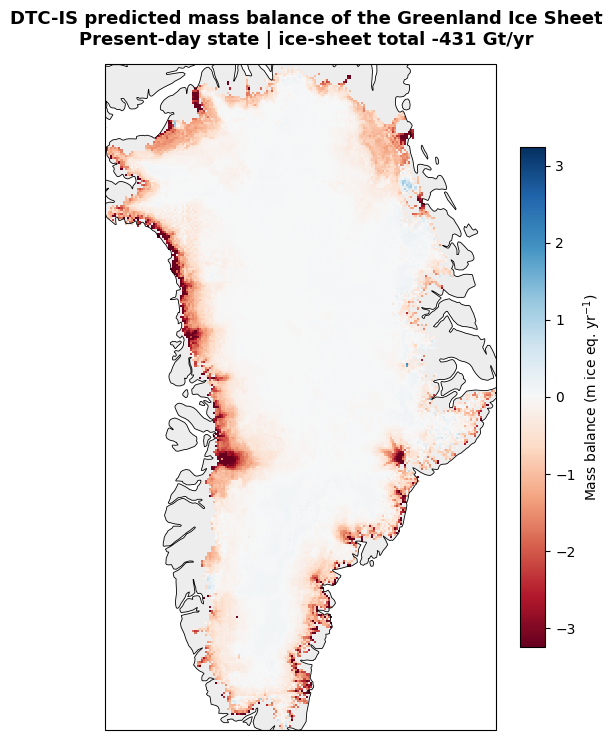

In [14]:
# control_ds is the unmodified run the scenario below is compared against; with the default parameters
# used here it is identical to the prediction, so only the prediction is downloaded.
predicted_ds, control_ds, prediction_summary = run_mass_balance_what_if()
predicted_ds = predicted_ds.compute()

dtcis_prediction_gt_yr = float(prediction_summary["total_mass_balance"])
print(f"DTC-IS predicted Greenland mass balance: {dtcis_prediction_gt_yr:.1f} Gt/yr")
print(f"Equivalent sea-level contribution:       {-dtcis_prediction_gt_yr / GT_PER_MM_SLE:.2f} mm/yr")
print(f"Model grid: {prediction_summary['x_res']} x {prediction_summary['y_res']} cells in {prediction_summary['crs']}")

plot_mass_balance_prediction_map(
    predicted_ds,
    plot_description_str=(
        "DTC-IS predicted mass balance of the Greenland Ice Sheet\n"
        f"Present-day state | ice-sheet total {dtcis_prediction_gt_yr:.0f} Gt/yr"
    ),
)

### Exploring "what-if" scenarios

The same model can be pushed away from the observed state to ask what the mass balance would be under a
different ice sheet. Three parameters are available:

- **Ice velocity factor** — scales the ice velocity field, standing in for a change in ice dynamics and
  therefore in discharge across the grounding line.
- **Surface temperature offset** — adds a constant offset in Kelvin to the surface temperature field, the
  most direct handle on surface melt.
- **Radar elevation factor** — scales the observed surface elevation change, i.e. how quickly the ice sheet
  is currently thinning.

Pick a scenario and press **Run scenario**. The left panel shows the predicted mass balance, the right panel
the difference to the control run, so the effect of your scenario is isolated from the pattern it acts on.

> These are illustrative explorations with a data-driven model, not projections from a coupled ice-sheet
> model. Large excursions from the observed state push the model outside the range it was trained on.

*Each scenario run takes about a minute.*

In [ ]:
ice_velocity_slider = widgets.FloatSlider(
    value=1.0, min=0.5, max=2.0, step=0.05, description="Ice velocity factor:", readout_format=".2f",
    style={"description_width": "initial"}, layout=widgets.Layout(width="450px"),
)
temperature_slider = widgets.FloatSlider(
    value=2.0, min=-2.0, max=5.0, step=0.25, description="Temperature offset [K]:", readout_format=".2f",
    style={"description_width": "initial"}, layout=widgets.Layout(width="450px"),
)
radar_elevation_slider = widgets.FloatSlider(
    value=1.0, min=0.5, max=2.0, step=0.05, description="Radar elevation factor:", readout_format=".2f",
    style={"description_width": "initial"}, layout=widgets.Layout(width="450px"),
)
scenario_button = widgets.Button(description="Run scenario", button_style="success")
scenario_status = widgets.Label(value="")
scenario_output = widgets.Output()


def on_scenario_clicked(b: Button) -> None:
    """
    Run the mass-balance model for the scenario set on the sliders and plot it against the control run.

    Parameters
    ----------
    b : Button
        The button widget that was clicked.
    """
    scenario_button.disabled = True
    scenario_status.value = "⏳ Running the mass balance model (this takes about a minute)..."
    try:
        scenario_ds, scenario_control_ds, scenario_summary = run_mass_balance_what_if(
            ice_velocity_factor=ice_velocity_slider.value,
            land_surface_temperature_offset=temperature_slider.value,
            radar_elevation_factor=radar_elevation_slider.value,
        )
        scenario_total = float(scenario_summary["total_mass_balance"])
        control_total = float(scenario_summary["control_mass_balance"])
        with scenario_output:
            clear_output(wait=True)
            print(f"Scenario mass balance: {scenario_total:.1f} Gt/yr")
            print(f"Control mass balance:  {control_total:.1f} Gt/yr")
            print(f"Difference:            {scenario_total - control_total:+.1f} Gt/yr")
            plot_mass_balance_prediction_map(
                scenario_ds.compute(),
                scenario_control_ds.compute(),
                plot_description_str=(
                    f"What-if scenario: ice velocity x{ice_velocity_slider.value:.2f}, "
                    f"temperature {temperature_slider.value:+.2f} K, "
                    f"radar elevation x{radar_elevation_slider.value:.2f}\n"
                    f"Ice-sheet total {scenario_total:.0f} Gt/yr "
                    f"({scenario_total - control_total:+.0f} Gt/yr against the control run)"
                ),
            )
        scenario_status.value = ""
    finally:
        scenario_button.disabled = False


scenario_button.on_click(on_scenario_clicked)
ipydisplay(ice_velocity_slider, temperature_slider, radar_elevation_slider, scenario_button, scenario_status)
ipydisplay(scenario_output)

FloatSlider(value=1.0, description='Ice velocity factor:', layout=Layout(width='450px'), max=2.0, min=0.5, ste…

FloatSlider(value=2.0, description='Temperature offset [K]:', layout=Layout(width='450px'), max=5.0, min=-2.0,…

FloatSlider(value=1.0, description='Radar elevation factor:', layout=Layout(width='450px'), max=2.0, min=0.5, …

Button(button_style='success', description='Run scenario', style=ButtonStyle())

Label(value='')

Output()

## 2. The annual DTC-IS mass-balance series

`GET /mass-balance/greenland` returns the precomputed DTC-IS mass-balance product for the Greenland Ice
Sheet: the radar-altimetry mass balance of Simonsen et al. (2021), stored as a point cloud with one value per
location and year together with its uncertainty. This is the record the machine-learning model above was
trained on, and it is the first of the two annual DTC-IS series that the rest of the notebook validates.

This series is labelled `simonsen` in the tables and figures below, after the product it comes from.

Summing over the ice sheet gives the annual total in Gt/yr. The uncertainties are summed **linearly** rather
than in quadrature: altimetry errors are spatially correlated, so a quadrature sum over tens of thousands of
points would understate the ice-sheet-wide uncertainty by roughly the square root of their number.

In [16]:
mass_balance_url = get_precomputed_mass_balance_dataset_url("greenland")
mass_balance_ds = xr.open_dataset(mass_balance_url, engine="zarr").compute()
print(f"Product: {mass_balance_url}")
print(f"{mass_balance_ds.sizes['point']} points x {mass_balance_ds.sizes['time']} years")

dtcis_annual = annual_series_from_mass_balance_dataset(mass_balance_ds)
print(
    f"DTC-IS annual series: {len(dtcis_annual)} years "
    f"({dtcis_annual['year'].min()}-{dtcis_annual['year'].max()}), "
    f"mean {dtcis_annual['simonsen_gt_yr'].mean():.1f} Gt/yr"
)
ipydisplay(dtcis_annual.head())

Product: http://dtc-query-api-bucket.s3-website.gra.io.cloud.ovh.net/sea_level_response/mass_balance/greenland_mass_balance.zarr/
67895 points x 28 years
DTC-IS annual series: 28 years (1992-2019), mean -162.7 Gt/yr


,year,simonsen_gt_yr,simonsen_unc_gt_yr
0,1992,-90.610764,51.307014
1,1993,-63.646065,50.541985
2,1994,-74.741676,50.819408
3,1995,0.241150,48.698139
4,1996,11.314965,50.364742


### Applying the model to each year's features

The what-if run in section 1 evaluates the machine-learning model on one epoch. The same model can instead be
evaluated **once per calendar year**, on the state the ice sheet was actually in that year, which turns the
prediction into a series that can be validated in its own right rather than compared against a decadal mean.

Only the time-varying features are rebuilt for each year; ice velocity, elevation, slope, firn thickness and
basal melt stay at their baseline values, exactly as in the training-time feature construction:

| Feature | Rebuilt per year from |
|---|---|
| `RAdh` | elevation change accumulated over the year, from the ESA CCI surface elevation change cube |
| `RAmode` | altimeter acquisition mode, LRM everywhere before the CryoSat-2 SARIn transition in October 2010 |
| `RAdist` | distance-to-track proxy, held at unity as the training feature processor does |
| `LST` | annual mean C3S surface temperature |

The predicted grid is integrated to an ice-sheet total the same way the what-if module does. This series is
labelled `mlmodel` below, against the `simonsen` product the model was trained on.

> **This step needs local input data.** The DTC Query API serves neither the ESA CCI elevation change nor the
> C3S surface temperature, so the two raw fields are read from a local DataPrep tree named by the environment
> variables `DTC_IS_DATAPREP_DIR` and `DTC_IS_LST_TABLE`. Without them the cell reports what is missing and
> the notebook carries on with the records that are available. The model itself and its baseline feature grid
> are downloaded from the public DTC-IS static files, so nothing else is needed.

*Each year re-interpolates the raw fields onto the model grid, so the cell takes a few minutes.*

In [17]:
# The years to predict. Widening the range is limited only by the coverage of the raw elevation-change file:
# a year needs at least two of its epochs before RAdh can be refreshed.
model_years = range(2003, 2024)

try:
    mlmodel_annual = predict_annual_mass_balance(model_years)
    print(
        f"DTC-IS ML model applied per year: {len(mlmodel_annual)} years "
        f"({mlmodel_annual['year'].min()}-{mlmodel_annual['year'].max()}), "
        f"mean {mlmodel_annual['mlmodel_gt_yr'].mean():.1f} Gt/yr"
    )
    for source, count in mlmodel_annual["mlmodel_source"].value_counts().items():
        print(f"  {count:2d} years with the features refreshed: {source}")
    ipydisplay(mlmodel_annual.head())
except TemporalFeaturesUnavailableError as unavailable:
    mlmodel_annual = pd.DataFrame()
    print(f"⚠️  No annual model prediction on this machine.\n    {unavailable}")

⚠️  No annual model prediction on this machine.
    The per-year model features need the raw ESA CCI elevation change and C3S surface temperature, neither of which the DTC Query API serves. Point $DTC_IS_DATAPREP_DIR at a DataPrep directory holding a file matching 'CCI_SEC_*dhdt_5km_*.nc', and optionally $DTC_IS_LST_TABLE at the annual temperature table.


## 3. Collecting the independent validation data

Two reference records are used, both of them community standards for Greenland, and both independent of the
radar-altimetry product above.

### IMBIE-3
The Ice Sheet Mass Balance Inter-comparison Exercise reconciles the three independent techniques (input-output
method, altimetry and gravimetry) into a single assessment. The release used here is the third one,
[Otosaka et al. (2026)](https://doi.org/10.5285/128c5e33-5224-4197-82f0-19dcc95b80a0), distributed by the UK
Polar Data Centre, which reconciles 24 individual Greenland surveys and runs monthly from 1971 to **2023**.
Each calendar year is the mean of its twelve monthly rates. Its uncertainty is averaged the same way rather
than reduced by the square root of the sample count, because the monthly uncertainties are dominated by
systematic terms and are near constant within a year. Years the release only partly covers are dropped, which
removes 1971.

> The earlier IPCC AR6 release, [Shepherd et al. (2021)](https://doi.org/10.5285/77b64c55-7166-4a06-9def-2e400398e452),
> stopped at 2020 and lays its file out differently. `load_imbie_annual` reads either, so passing
> `url=IMBIE_2021_GREENLAND_URL` reproduces the comparison against that record instead. The two differ by more
> than 100 Gt/yr in some years — 2020 is -275 Gt/yr in IMBIE-3 against -397 Gt/yr in the AR6 release — so it is
> worth knowing which one a published DTC-IS residual was measured against.

### Gravimetric mass balance (GMB) from GRACE and GRACE-FO
The GRACE and GRACE-FO satellites weigh the ice sheet by measuring its gravitational pull, which is entirely
independent of how its surface moves. The series used here is the basin-averaged Greenland ice-mass product
from [GravIS COST-G](https://doi.org/10.5880/COST-G.GRAVIS_02_L3_ICE) (Sasgen, AWI), the same product family
the DTC-IS uses for its Antarctic mass balance.

The GMB record is a *cumulative* mass anomaly, so an annual rate has to be derived from it. Here the rate for
year Y is the mass difference between 1 January Y and 1 January Y+1: differencing over a full 12-month cycle
cancels the Greenland seasonal signal and matches the definition of annual mass balance used by the other two
records. A least-squares trend through a single calendar year does not: the cumulative curve peaks in spring
and falls steeply through the melt season, so a straight line through January to December is dominated by that
asymmetry.

Years the gravimetry cannot support are dropped automatically — too few epochs, no epoch close enough to a
year boundary, or a sampling gap inside the year. This removes **2017 and 2018**, the years spanning the end
of GRACE and the start of GRACE-FO, along with the year the record currently ends in.

*Both files are downloaded once and then cached.*

In [18]:
imbie_annual = load_imbie_annual()
print(f"IMBIE-3 (doi:{IMBIE_DOI})")
print(f"  source: {IMBIE_GREENLAND_URL[:80]}...")
print(
    f"  {len(imbie_annual)} complete years ({imbie_annual['year'].min()}-{imbie_annual['year'].max()}), "
    f"mean {imbie_annual['imbie_gt_yr'].mean():.1f} Gt/yr"
)

gmb_cumulative = load_gravimetric_cumulative()
gmb_annual = annual_rates_from_cumulative(gmb_cumulative)
print(f"\nGMB, GRACE/GRACE-FO (doi:{GRAVIS_DOI})")
print(f"  source: {GRAVIS_GREENLAND_URL}")
print(
    f"  {len(gmb_cumulative)} monthly epochs "
    f"({gmb_cumulative['decimal_year'].min():.2f}-{gmb_cumulative['decimal_year'].max():.2f}) "
    f"-> {len(gmb_annual)} annual rates"
)
missing_years = sorted(
    set(range(int(gmb_annual["year"].min()), int(gmb_annual["year"].max()) + 1)) - set(gmb_annual["year"])
)
print(f"  years the record cannot support: {missing_years}")
ipydisplay(gmb_annual.head())

IMBIE-3 (doi:10.5285/77b64c55-7166-4a06-9def-2e400398e452)
  source: https://ramadda.data.bas.ac.uk/repository/entry/get?entryid=synth%3A77b64c55-716...
  29 complete years (1992-2020), mean -168.7 Gt/yr

GMB, GRACE/GRACE-FO (doi:10.5880/COST-G.GRAVIS_02_L3_ICE)
  source: https://isdc-data.gfz.de/grace/GravIS/COST-G/Level-3/ICE/GIS/GRAVIS-3_COSTG_0200_GIS_BAVE_AWI_0001.asc
  252 monthly epochs (2002.29-2025.96) -> 20 annual rates
  years the record cannot support: [2017, 2018]


,year,gmb_gt_yr,gmb_unc_gt_yr,gmb_n
0,2003,-157.456668,27.181115,11
1,2004,-168.433963,21.807713,12
2,2005,-216.654169,20.360734,12
3,2006,-227.030450,20.587932,12
4,2007,-204.593600,19.555048,12


## 4. The intercomparison table

The four annual series are now joined onto a common set of calendar years, together with the difference of
every pairing. The comparison window below is the full common record; narrow it to look at a specific period,
for example the GRACE era (2003 onwards) or the years before the 2010 melt anomaly.

The table reads left to right as the four records, their 1σ uncertainties, and then the difference of every
pairing. Two of those columns carry most of the meaning. `GMB - IMBIE` shows how far the two independent
references sit from **each other** in the same year, which is the scale against which every DTC-IS residual
should be judged. `ML model - DTC-IS` is the model against the product it was trained on, so it isolates
what the model adds or loses relative to its own training target.

In [19]:
start_year = None  # e.g. 2003 to restrict the comparison to the GRACE era
end_year = None  # e.g. 2019 to stop where the DTC-IS product ends

comparison = build_intercomparison_table(
    [dtcis_annual, mlmodel_annual, imbie_annual, gmb_annual], start_year=start_year, end_year=end_year
)
ipydisplay(format_intercomparison_table(comparison))

,DTC-IS,DTC-IS 1σ,IMBIE,IMBIE 1σ,GMB,GMB 1σ,DTC-IS - IMBIE,DTC-IS - GMB,GMB - IMBIE
year,,,,,,,,,
1992,-90.6,51.3,-7.8,56.4,NaN,NaN,-82.8,NaN,NaN
1993,-63.6,50.5,-24.4,56.4,NaN,NaN,-39.3,NaN,NaN
1994,-74.7,50.8,-106.3,56.4,NaN,NaN,31.5,NaN,NaN
1995,0.2,48.7,-45.1,77.5,NaN,NaN,45.4,NaN,NaN
1996,11.3,50.4,8.0,78.5,NaN,NaN,3.3,NaN,NaN
1997,2.1,49.2,-4.7,80.2,NaN,NaN,6.8,NaN,NaN
1998,-95.3,45.4,-54.5,80.2,NaN,NaN,-40.8,NaN,NaN
1999,-147.6,48.0,-74.4,79.8,NaN,NaN,-73.2,NaN,NaN
2000,-110.3,44.3,-29.5,78.7,NaN,NaN,-80.8,NaN,NaN


### Agreement statistics

Each pairing is given the same statistics, so the DTC-IS numbers can be read against the numbers the two
references score against one another. The model prediction is scored against both references and against
the product it was trained on:

- **Bias** is the mean difference: a systematic offset between the two records.
- **MAE and RMSE** measure the size of the year-to-year disagreement; RMSE punishes single bad years harder.
- **R² and Pearson r** ask how much of the interannual variability the two records share. R² can turn negative
  when a systematic offset or a few outlying years dominate, even where the correlation stays high.
- **Cumulative bias** converts the accumulated difference over the compared years into millimetres of sea
  level, which is the quantity that matters downstream in the DTC-IS sea-level chain.

In [20]:
metrics = compute_all_metrics(comparison)
ipydisplay(metrics_summary_table(metrics))

print(f"\nDTC-IS present-day prediction: {dtcis_prediction_gt_yr:.1f} Gt/yr")
for name, column in (("IMBIE", "imbie_gt_yr"), ("GMB", "gmb_gt_yr")):
    recent = comparison.dropna(subset=[column]).tail(10)
    mean_rate = recent[column].mean()
    print(
        f"  vs the ten most recent {name} years "
        f"({int(recent['year'].min())}-{int(recent['year'].max())}, "
        f"mean {mean_rate:.0f}, range {recent[column].max():.0f} to {recent[column].min():.0f} Gt/yr): "
        f"{dtcis_prediction_gt_yr - mean_rate:+.0f} Gt/yr"
    )

if not mlmodel_annual.empty:
    modelled = comparison.dropna(subset=["mlmodel_gt_yr"])
    print(
        f"\nAnnual model prediction over {int(modelled['year'].min())}-{int(modelled['year'].max())}: "
        f"mean {modelled['mlmodel_gt_yr'].mean():.0f} Gt/yr, "
        f"range {modelled['mlmodel_gt_yr'].max():.0f} to {modelled['mlmodel_gt_yr'].min():.0f} Gt/yr"
    )

,DTC-IS vs IMBIE,DTC-IS vs GMB,GMB vs IMBIE
Years compared,28 (1992-2019),15 (2003-2019),16 (2003-2020)
Mean A / B [Gt/yr],-162.7 / -160.5,-250.1 / -248.7,-244.3 / -254.5
Bias A - B [Gt/yr],-2.2,-1.4,+10.2
MAE / RMSE [Gt/yr],52.6 / 67.7,51.1 / 68.2,61.4 / 89.5
R2 / Pearson r,0.637 / 0.850,0.702 / 0.840,-0.185 / 0.685
Cumulative A / B [Gt],-4557 / -4495,-3751 / -3730,-3909 / -4072
Cumulative bias [mm SLE],+0.17,+0.06,-0.45



DTC-IS present-day prediction: -431.5 Gt/yr
  vs the ten most recent IMBIE years (2011-2020, mean -251, range -86 to -444 Gt/yr): -180 Gt/yr
  vs the ten most recent GMB years (2013-2024, mean -178, range -11 to -488 Gt/yr): -253 Gt/yr


## 5. The validation figure

The four panels show the same comparison from four angles:

- **(a) Annual mass balance** — every record with its uncertainty, and the present-day DTC-IS prediction as a
  horizontal line. The bars are IMBIE, the line with diamonds is the DTC-IS product with its uncertainty band,
  the squares are the gravimetric rates, and the line with triangles is the machine-learning model applied to
  each year's own features. Reading that line against the horizontal one shows how much of the difference
  between the present-day prediction and the observed years is the model responding to a particular year.
- **(b) Cumulative mass change** — the annual rates accumulated and tied to zero at the first GMB epoch, so
  the spread is the disagreement accumulated *during* the common period rather than inherited from the decade
  before GRACE launched. The right-hand axis gives the sea-level contribution. The raw gravimetric curve is
  drawn as observed, with the GRACE to GRACE-FO gap left open.
- **(c) Pairwise agreement** — every pairing against the 1:1 line, with its regression line and statistics.
  Markers name the series being evaluated (diamonds the DTC-IS product, triangles the model), colours name
  the reference it is being judged against.
- **(d) Annual differences** — the residual of every pairing year by year, with its mean as a dashed line.
  Colours name the reference each pairing is judged against and hatching names the series being judged: plain
  bars are the DTC-IS product, diagonal hatching the model, and cross hatching the two references against each
  other, which is the spread every other bar should be read against.

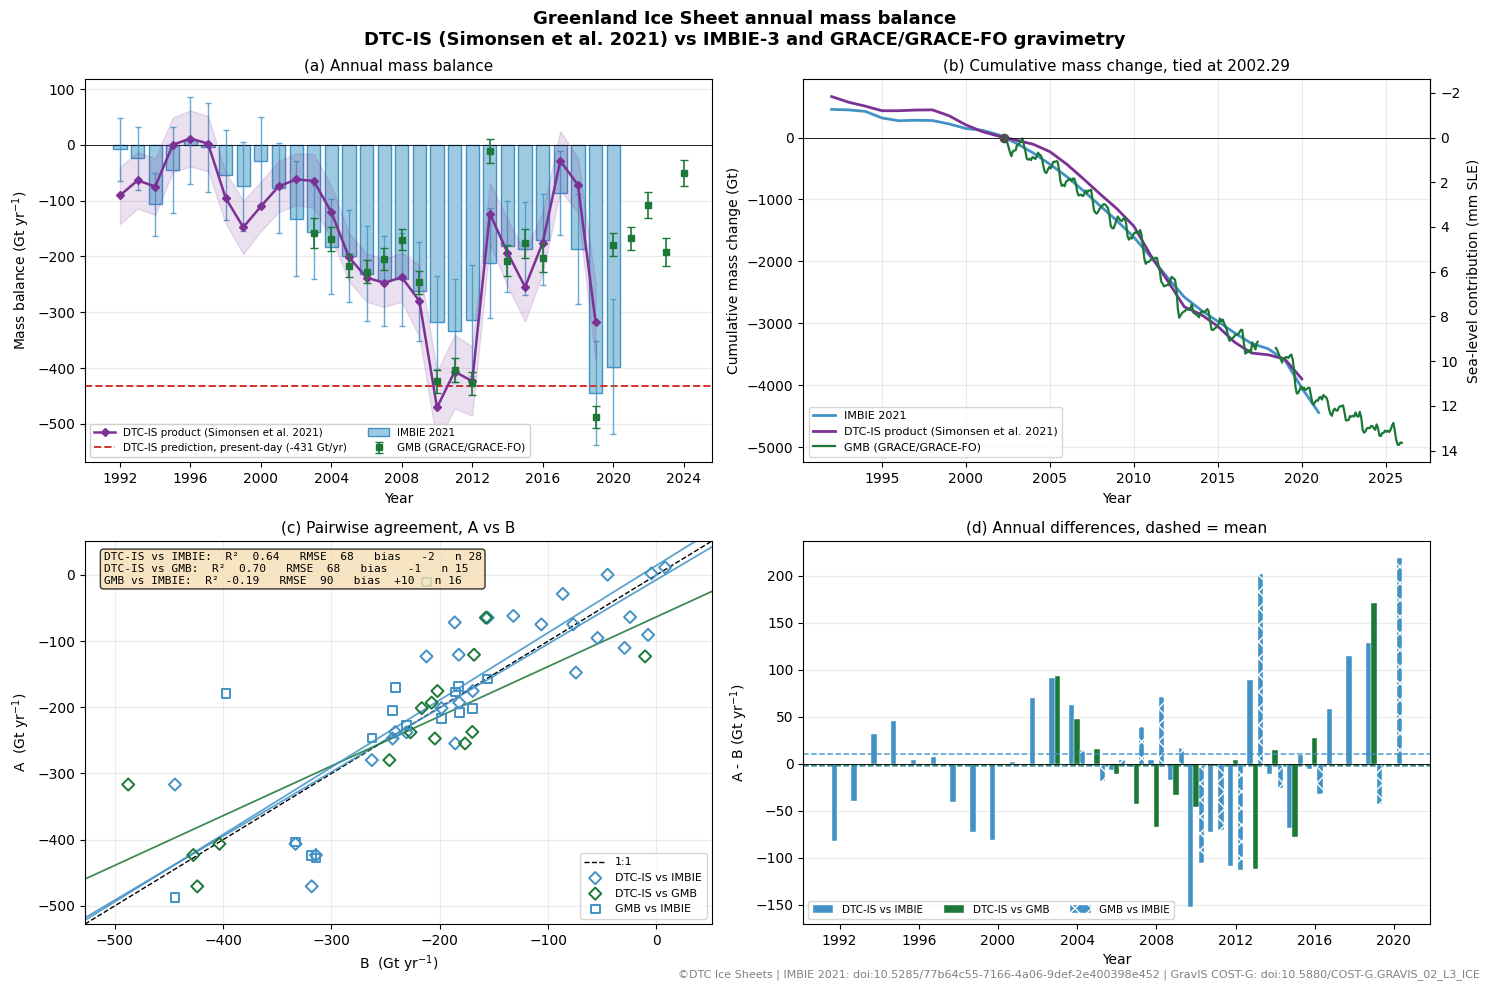

In [21]:
plot_mb_validation_four_panels(
    comparison,
    metrics,
    gmb_cumulative=gmb_cumulative,
    what_if_total_gt_yr=dtcis_prediction_gt_yr,
    plot_description_str=(
        "Greenland Ice Sheet annual mass balance\n"
        "DTC-IS (Simonsen et al. 2021) vs IMBIE-3 and GRACE/GRACE-FO gravimetry"
    ),
)

## 6. Reading the result

A few things are worth keeping in mind when interpreting the statistics above.

- **The present-day prediction is not an observed year.** The what-if prediction integrates the *current*
  state of the ice sheet, including how fast it is thinning right now, into a single rate. It is compared
  above against the mean of the ten most recent observed years, but it sits towards the extreme end of the
  observed range rather than near its mean, so treat it as the model's read of the present state rather than
  as a validated annual estimate.
- **The model and its training product are two different things.** The `simonsen` series is the radar-altimetry
  product the model was trained on; the `mlmodel` series is what the model predicts when it is given each
  year's own features. Where the two part company the model is generalising away from its training target,
  which is worth reading against the references rather than treating as an error on its own.
- **The annual model prediction is only as temporal as its features.** Only elevation change, acquisition
  mode and surface temperature are rebuilt per year; ice velocity and the static properties are held at
  their baseline values, so the series carries less interannual variability than a fully time-resolved run
  would. Years in which the surface temperature could not be refreshed, named in the `mlmodel_source`
  column, are weaker still.
- **The references disagree with each other too.** In several years IMBIE and the gravimetry differ by more
  than 100 Gt/yr — comparable to, or larger than, the DTC-IS residual in the same year. A DTC-IS residual only
  indicates a problem in the digital twin when it is clearly outside that spread.
- **Different definitions of a year.** The DTC-IS product and the gravimetric rates are calendar-year
  quantities, while the IMBIE rate is a smoothed monthly derivative averaged over the year. Around sharp melt
  anomalies, such as 2012 and 2019, that smoothing alone shifts mass between neighbouring years.
- **The extremes are where the records part ways.** Agreement is good in ordinary years and degrades in the
  extreme ones, which is precisely where the largest observational uncertainties sit.
- **Endpoint years are the weakest.** The last year of the IMBIE release and the years bracketing the
  GRACE to GRACE-FO gap are the least constrained values in either reference.
- **A reference record is not fixed.** IMBIE-3 revised several years of the AR6 release substantially, 2019
  and 2020 by more than 100 Gt/yr, and tightened its uncertainties throughout. A DTC-IS residual is a
  statement about a particular release, so it is worth recording which one was used.
- **Cumulative bias is the number for the sea-level chain.** A small annual bias that keeps its sign
  accumulates: the cumulative bias in millimetres of sea level says how much the choice of record would change
  the sea-level contribution fed into the SELREM module in the sea-level notebooks.

You can now go back and change the comparison window, or rerun the whole notebook with a what-if scenario, to
see how sensitive the conclusions are to those choices.

### Saving the results

The cell below writes the intercomparison table and the statistics to CSV next to the notebook.

In [11]:
output_dir = "greenland_mb_validation_output"
os.makedirs(output_dir, exist_ok=True)

comparison.to_csv(os.path.join(output_dir, "greenland_annual_mb_intercomparison.csv"), index=False)
metrics_summary_table(metrics).to_csv(os.path.join(output_dir, "greenland_annual_mb_metrics.csv"))
print(f"Saved the intercomparison table and statistics to ./{output_dir}/")

Saved the intercomparison table and statistics to ./greenland_mb_validation_output/


## References

- Simonsen, S. B., Barletta, V. R., Colgan, W. T., & Sørensen, L. S. (2021). Greenland Ice Sheet mass balance
  (1992-2020) from calibrated radar altimetry. *Geophysical Research Letters*, 48, e2020GL091216.
  [doi:10.1029/2020GL091216](https://doi.org/10.1029/2020GL091216)
- The IMBIE Team / Otosaka, I. N. et al. (2026). Mass balance of the Greenland and Antarctic Ice Sheets from
  the 1970s to 2023. NERC EDS UK Polar Data Centre.
  [doi:10.5285/128c5e33-5224-4197-82f0-19dcc95b80a0](https://doi.org/10.5285/128c5e33-5224-4197-82f0-19dcc95b80a0)
- The IMBIE Team / Shepherd, A. et al. (2021). Antarctic and Greenland Ice Sheet mass balance 1992-2020 for
  IPCC AR6. NERC EDS UK Polar Data Centre.
  [doi:10.5285/77b64c55-7166-4a06-9def-2e400398e452](https://doi.org/10.5285/77b64c55-7166-4a06-9def-2e400398e452)
- Sasgen, I. et al. GravIS COST-G Level-3 ice-mass products (GRACE/GRACE-FO), GFZ Data Services.
  [doi:10.5880/COST-G.GRAVIS_02_L3_ICE](https://doi.org/10.5880/COST-G.GRAVIS_02_L3_ICE)
- Groh, A., & Horwath, M. (2021). Antarctic ice mass change products from GRACE/GRACE-FO using tailored
  sensitivity kernels. *Remote Sensing*, 13(9), 1736. [doi:10.3390/rs13091736](https://doi.org/10.3390/rs13091736)

Thank you for using the DTC-IS mass-balance validation notebook. Feedback, and suggestions for further
reference records to include, are very welcome.